In [1]:
from julia.api import Julia
from julia import Main

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from multiprocessing import Pool
from concurrent.futures import ProcessPoolExecutor
import concurrent.futures

import scipy.special as sp
import os
import sys

from pathlib import Path
import shutil

sys.path.insert(0, str(Path("../JAMDiFF_library").resolve()))
from get_JAM_DiFF import get_JAM_DiFF_dict

import pickle

Settings

In [2]:
c = 1/2

fit_name = "Default"

if_generate_grids = False

N_replicas = 100

N_cores = 16

sidis_plot_n_points = 45
ee_aut_plot_n_points = 45
ee_eec_plot_n_points = 45

Read Files

In [3]:
Main.eval('using Distributed')
Main.eval(f'addprocs({N_cores})')

fitting_root = "../"
def include(name):
    path = os.path.join(fitting_root, name)
    Main.eval(f'@everywhere include(raw"{path}")')

card_name = fit_name.removesuffix(".jl")
include(f"Cards/{card_name}.jl")

# PDF
include("Collinear_PDF/pdf.jl")
# Core
include("Core/constants.jl")
include("Core/strong coupling.jl")
# Numerical
include("Numerical/FastGK.jl")
# DiFF 
include("DiFF_EEC/DiFF_EEC.jl")
include("Processes/SIDIS/SIDIS_AUT.jl")
include("Processes/ee/ee_AUT.jl")
include("Processes/ee/ee_EEC.jl")

wdir = Main.eval("wdir")
results_dir_name = Main.eval("results_dir_name")
scan_grid_name = str(Main.eval("scan_grid_name"))
scan_coeffs_path = Path(f"{scan_grid_name}.xlsx")
dict_raw_DiFF_name = str(Main.eval("dict_raw_DiFF_name"))
dict_raw_DiFF_path = Path("../Grids") / f"{dict_raw_DiFF_name}.pkl"


      From worker 2:	LHAPDF 6.5.5 loading /home/maxzhang/UCLA_QCD_fitter/DiFF/.runtime/lhapdf-data/CT18NLO/CT18NLO_0000.dat
      From worker 2:	CT18NLO PDF set, member #0, version 1; LHAPDF ID = 14400
      From worker 6:	LHAPDF 6.5.5 loading /home/maxzhang/UCLA_QCD_fitter/DiFF/.runtime/lhapdf-data/CT18NLO/CT18NLO_0000.dat
      From worker 6:	CT18NLO PDF set, member #0, version 1; LHAPDF ID = 14400
      From worker 6:	LHAPDF 6.5.5 loading /home/maxzhang/UCLA_QCD_fitter/DiFF/.runtime/lhapdf-data/JAMDiFF23-transversity_lo/JAMDiFF23-transversity_lo_0000.dat
      From worker 6:	JAMDiFF23-transversity_lo PDF set, member #0, version 1; LHAPDF ID = 1
      From worker 4:	LHAPDF 6.5.5 loading /home/maxzhang/UCLA_QCD_fitter/DiFF/.runtime/lhapdf-data/CT18NLO/CT18NLO_0000.dat
      From worker 4:	CT18NLO PDF set, member #0, version 1; LHAPDF ID = 14400
      From worker 4:	LHAPDF 6.5.5 loading /home/maxzhang/UCLA_QCD_fitter/DiFF/.runtime/lhapdf-data/JAMDiFF23-transversity_lo/JAMDiFF23-transve

Generate JAM DiFFs 

In [4]:
z_array=np.linspace(0.19,0.99,20)  
Mh_array=np.linspace(0.28,2.05,50)
Q_array = [2,3.65,7,8.5,10,10.58]

In [5]:
kinds = ["D1", "H1a"]
mu_array = c*np.array(Q_array)
if if_generate_grids:

    dict_raw_DiFF = get_JAM_DiFF_dict(
        z_array=z_array, Mh_array=Mh_array, mu_array=mu_array, kinds=kinds, wdir=wdir
    )

    with open(dict_raw_DiFF_path, "wb") as f:
        pickle.dump(dict_raw_DiFF, f, protocol=pickle.HIGHEST_PROTOCOL)

else:
    with open(dict_raw_DiFF_path, "rb") as f:
        dict_raw_DiFF = pickle.load(f)

keys = [k for k in dict_raw_DiFF.keys() if isinstance(k, tuple)]
Main.dict_raw_DiFF = {k: v for k, v in dict_raw_DiFF.items()}
Main.eval('''let payload = dict_raw_DiFF
    @everywhere global dict_raw_DiFF = $payload
end''')

Construct JAM DiFF Interpolators

In [6]:
all_replica_ids = np.asarray(sorted({k[2] for k in keys if k[2] > 0}), dtype=int)
N_total = len(all_replica_ids)

n_selected = min(int(N_replicas), N_total)
selected_positive_replica_ids = np.asarray(
    np.random.choice(all_replica_ids, size=n_selected, replace=False),
    dtype=int,
)
selected_positive_replica_ids = np.sort(selected_positive_replica_ids)
replica_ids = np.sort(np.concatenate(([0], selected_positive_replica_ids)))
selected_keys = [k for k in keys if k[2] in set(replica_ids.tolist())]

Main.selected_keys = selected_keys
Main.eval('''let payload = selected_keys
    @everywhere global selected_keys = $payload
end''')

include("Grids/initialization.jl")

print(f"Loaded {len(selected_positive_replica_ids)} replica(s) plus replica 0.")


Loaded 100 replica(s) plus replica 0.


Test & Warm Up SIDIS AUT

In [7]:
chi_deg = 10.0
chi = np.deg2rad(chi_deg)

Main.a_D1 = 0.1
Main.b_D1 = 0.1
Main.a_H1a = 0.1
Main.b_H1a = 0.1
Main.eval('''@everywhere begin
    global a_D1 = 0.1
    global b_D1 = 0.1
    global a_H1a = 0.1
    global b_H1a = 0.1
end''')

value = Main.SIDIS_EEC_AUT(
    chi=chi, # chi in radians
    x=0.1,   # x
    Q=2.0,  # Q
    mu=1.0, # scale
    rep=0,   # replica id
)

warmup_values, warmup_time = Main.SIDIS_EEC_AUT_pmap(
    chi_array=[chi, chi],
    x_array=[0.1, 0.1],
    Q_array=[2.0, 2.0],
    mu_array=[1.0, 1.0],
    rep=[0, 0],
)

display(value)
display((len(warmup_values), warmup_time))

0.010187160327842247

(2, 2.699026685)

SIDIS AUT Parameter Scan And Plotting

In [8]:
import time
from IPython.display import clear_output

PERCENTILE_LEVELS = np.asarray([16.0, 50.0, 84.0], dtype=float)

plot_data_dir = Path("Plot_Data") / card_name
plot_data_dir.mkdir(parents=True, exist_ok=True)


def _format_seconds(seconds):
    seconds = max(float(seconds), 0.0)
    if seconds < 60:
        return f"{seconds:.1f}s"
    minutes, sec = divmod(int(round(seconds)), 60)
    if minutes < 60:
        return f"{minutes}m {sec:02d}s"
    hours, minutes = divmod(minutes, 60)
    return f"{hours}h {minutes:02d}m {sec:02d}s"


def _save_plot_data(filename, payload):
    path = plot_data_dir / filename
    with path.open("wb") as f:
        pickle.dump(payload, f, protocol=pickle.HIGHEST_PROTOCOL)
    print(f"Saved plot data to {path}")
    return path


def _apply_percentile_summary(entry, samples, fallback_samples, prefix):
    samples = np.asarray(samples, dtype=float)
    if samples.size:
        summary_samples = samples
    else:
        summary_samples = np.asarray(fallback_samples, dtype=float)

    if summary_samples.ndim != 2 or summary_samples.shape[0] == 0:
        raise ValueError("No sample curves available for percentile summary")

    percentile_16, percentile_50, percentile_84 = np.percentile(
        summary_samples,
        PERCENTILE_LEVELS,
        axis=0,
    )

    entry[f"{prefix}_percentile_16"] = np.asarray(percentile_16, dtype=float)
    entry[f"{prefix}_percentile_50"] = np.asarray(percentile_50, dtype=float)
    entry[f"{prefix}_percentile_84"] = np.asarray(percentile_84, dtype=float)
    entry[f"{prefix}_median"] = np.asarray(percentile_50, dtype=float)
    entry[f"{prefix}_lower_68"] = np.asarray(percentile_16, dtype=float)
    entry[f"{prefix}_upper_68"] = np.asarray(percentile_84, dtype=float)
    entry["n_members"] = int(summary_samples.shape[0])


def _save_scan_plot_data(scan_results, *, filename, value_prefix, root_keys=None, entry_keys=None):
    root_keys = list(root_keys or [])
    entry_keys = list(entry_keys or [])

    payload = {
        "card_name": card_name,
        "process": scan_results["process"],
        "fit_order": scan_results["fit_order"],
        "scan_label": scan_results["scan_label"],
        "coeffs_path": scan_results["coeffs_path"],
        "coeff_grid": np.asarray(scan_results["coeff_grid"], dtype=float),
        "replica_ids": np.asarray(scan_results["replica_ids"], dtype=int),
        "percentiles": PERCENTILE_LEVELS.copy(),
        "by_kinematics": {},
    }

    for key in root_keys:
        payload[key] = scan_results[key]

    for key, entry in scan_results["by_kinematics"].items():
        compact_entry = {name: entry[name] for name in entry_keys}
        compact_entry.update({
            "percentile_16": np.asarray(entry[f"{value_prefix}_percentile_16"], dtype=float),
            "percentile_50": np.asarray(entry[f"{value_prefix}_percentile_50"], dtype=float),
            "percentile_84": np.asarray(entry[f"{value_prefix}_percentile_84"], dtype=float),
            "median": np.asarray(entry[f"{value_prefix}_median"], dtype=float),
            "lower_68": np.asarray(entry[f"{value_prefix}_lower_68"], dtype=float),
            "upper_68": np.asarray(entry[f"{value_prefix}_upper_68"], dtype=float),
            "n_members": int(entry["n_members"]),
        })
        payload["by_kinematics"][key] = compact_entry

    path = _save_plot_data(filename, payload)
    scan_results["plot_data_path"] = str(path)
    return path


def set_diff_coeffs(a, b):
    a = float(a)
    b = float(b)
    Main.a_D1 = a
    Main.b_D1 = b
    Main.a_H1a = a
    Main.b_H1a = b
    Main.eval(
        f'''@everywhere begin
            global a_D1 = {a}
            global b_D1 = {b}
            global a_H1a = {a}
            global b_H1a = {b}
        end'''
    )


def _format_q_label(Q):
    Q = float(Q)
    if Q.is_integer():
        return str(int(Q))
    return f"{Q:g}".replace('.', 'p')


def _read_scan_coeffs(path):
    path = Path(path)
    df = pd.read_excel(path, header=None)
    if df.shape[1] < 2:
        raise ValueError(f"Expected at least two columns in {path}")

    df = df.iloc[:, :2].copy()
    df.columns = ["a", "b"]
    df = df.apply(pd.to_numeric, errors="coerce").dropna(how="any").reset_index(drop=True)
    if df.empty:
        raise ValueError(f"No valid (a, b) pairs found in {path}")

    return df[["a", "b"]].to_numpy(dtype=float)


def _normalize_replica_ids(replica_ids=None):
    if replica_ids is None:
        return np.asarray(selected_positive_replica_ids, dtype=int)
    if isinstance(replica_ids, str):
        if replica_ids.lower() in {"loaded", "default"}:
            return np.asarray(selected_positive_replica_ids, dtype=int)
        raise ValueError(f"Unsupported replica selection: {replica_ids}")

    replica_ids = np.asarray(replica_ids, dtype=int)
    if replica_ids.ndim != 1:
        raise ValueError("replica_ids must be one-dimensional")
    if replica_ids.size == 0:
        return replica_ids

    unknown = np.setdiff1d(replica_ids, selected_positive_replica_ids)
    if unknown.size:
        raise ValueError(f"Requested replica ids were not loaded: {unknown.tolist()}")
    return np.unique(replica_ids)


def _print_progress(jobs_done, total_jobs, started_at, label):
    elapsed = time.perf_counter() - started_at
    avg_time = elapsed / max(jobs_done, 1)
    eta = avg_time * max(total_jobs - jobs_done, 0)
    clear_output(wait=True)
    print(f"[{jobs_done}/{total_jobs}] {label} | remaining={_format_seconds(eta)}")


def _resolve_x_q_inputs(*, x_list=None, Q_list=None, x_q_map=None):
    if x_q_map is not None:
        x_values = [float(x) for x in x_q_map.keys()]
        x_to_q = {float(x): [float(Q) for Q in x_q_map[x]] for x in x_q_map.keys()}
    else:
        if x_list is None or Q_list is None:
            raise ValueError("Provide either x_q_map or both x_list and Q_list")
        x_values = [float(x) for x in x_list]
        q_values = [float(Q) for Q in Q_list]
        x_to_q = {x: list(q_values) for x in x_values}

    x_q_pairs = [(x, Q) for x in x_values for Q in x_to_q[x]]
    return x_values, x_to_q, x_q_pairs


def _prepare_sidis_kinematics(*, x_list=None, Q_list=None, x_q_map=None, chi_deg_array=None):
    if chi_deg_array is None:
        chi_deg_array = np.linspace(1, 30, 30)

    x_values, x_to_q, x_q_pairs = _resolve_x_q_inputs(x_list=x_list, Q_list=Q_list, x_q_map=x_q_map)
    kinematics = {}
    for x, Q in x_q_pairs:
        chi_deg_valid = []
        chi_valid = []
        for chi_deg in chi_deg_array:
            chi = np.deg2rad(chi_deg)
            z = (1 - np.cos(chi)) / 2
            if np.sqrt(z) * Q > 7:
                continue
            chi_deg_valid.append(float(chi_deg))
            chi_valid.append(float(chi))

        if not chi_valid:
            raise ValueError(f"No valid chi points survived for x={x:.2f}, Q={Q:g}")

        chi_array = np.asarray(chi_valid, dtype=float)
        kinematics[(float(x), float(Q))] = {
            "x": float(x),
            "Q": float(Q),
            "chi_deg": np.asarray(chi_deg_valid, dtype=float),
            "chi_array": chi_array,
            "mu_array": np.full(chi_array.size, float(c * Q), dtype=float),
            "x_array": np.full(chi_array.size, float(x), dtype=float),
            "Q_array": np.full(chi_array.size, float(Q), dtype=float),
        }
    return x_values, x_to_q, kinematics


def _run_sidis_central_curve(kin):
    values, _ = Main.SIDIS_EEC_AUT_pmap(
        chi_array=kin["chi_array"],
        x_array=kin["x_array"],
        Q_array=kin["Q_array"],
        mu_array=kin["mu_array"],
        rep=np.zeros(kin["chi_array"].size, dtype=int),
    )
    return np.asarray(values, dtype=float)


def _run_sidis_replica_curves(kin, replica_ids):
    n_reps = len(replica_ids)
    n_chi = kin["chi_array"].size
    if n_reps == 0:
        return np.empty((0, n_chi), dtype=float)

    values, _ = Main.SIDIS_EEC_AUT_pmap(
        chi_array=np.tile(kin["chi_array"], n_reps),
        x_array=np.tile(kin["x_array"], n_reps),
        Q_array=np.tile(kin["Q_array"], n_reps),
        mu_array=np.tile(kin["mu_array"], n_reps),
        rep=np.repeat(replica_ids, n_chi),
    )
    return np.asarray(values, dtype=float).reshape(n_reps, n_chi)


def generate_sidis_aut_scan_results(*, x_list=None, Q_list=None, x_q_map=None, coeffs_path, replica_ids=None, fit_order="LO", chi_deg_array=None, save_plot_data=True):
    if fit_order != "LO":
        raise ValueError("Only LO is currently supported")

    coeff_grid = _read_scan_coeffs(coeffs_path)
    replica_ids = _normalize_replica_ids(replica_ids)
    scan_label = Path(coeffs_path).stem
    x_values, x_to_q, kinematics = _prepare_sidis_kinematics(
        x_list=x_list,
        Q_list=Q_list,
        x_q_map=x_q_map,
        chi_deg_array=chi_deg_array,
    )

    scan_results = {
        "process": "SIDIS_AUT",
        "fit_order": fit_order,
        "scan_label": scan_label,
        "coeffs_path": str(Path(coeffs_path).resolve()),
        "coeff_grid": coeff_grid,
        "replica_ids": replica_ids,
        "x_values": x_values,
        "x_to_q": x_to_q,
        "by_kinematics": {},
    }

    n_coeffs = len(coeff_grid)
    n_reps = len(replica_ids)
    for key, kin in kinematics.items():
        n_chi = kin["chi_array"].size
        scan_results["by_kinematics"][key] = {
            **kin,
            "central_curves": np.empty((n_coeffs, n_chi), dtype=float),
            "replica_curves": np.empty((n_coeffs, n_reps, n_chi), dtype=float),
        }

    total_jobs = n_coeffs * len(kinematics)
    jobs_done = 0
    t0_all = time.perf_counter()

    for icoeff, (a, b) in enumerate(coeff_grid):
        set_diff_coeffs(a, b)
        for (x, Q), entry in scan_results["by_kinematics"].items():
            entry["central_curves"][icoeff] = _run_sidis_central_curve(entry)
            entry["replica_curves"][icoeff] = _run_sidis_replica_curves(entry, replica_ids)
            jobs_done += 1
            _print_progress(jobs_done, total_jobs, t0_all, f"SIDIS a={a:.4f}, b={b:.4f}, x={x:.2f}, Q={Q:g}")

    for entry in scan_results["by_kinematics"].values():
        members = entry["replica_curves"].reshape(-1, entry["replica_curves"].shape[-1])
        _apply_percentile_summary(entry, members, entry["central_curves"], "AUT")

    if save_plot_data:
        _save_scan_plot_data(
            scan_results,
            filename="sidis_aut.pkl",
            value_prefix="AUT",
            root_keys=["x_values", "x_to_q"],
            entry_keys=["x", "Q", "chi_deg", "chi_array", "mu_array"],
        )

    total_elapsed = time.perf_counter() - t0_all
    clear_output(wait=True)
    print(
        f"done | SIDIS scan={scan_label} | "
        f"parameter points={len(coeff_grid)} | replicas={len(replica_ids)} | "
        f"total elapsed: {_format_seconds(total_elapsed)}"
    )

    return scan_results


def plot_sidis_aut_scan_results(*, scan_results, x_list=None, Q_list=None, x_q_map=None, title_note=None):
    print(f"Results for {scan_results['fit_order']}")
    print(
        f"scan={scan_results['scan_label']} | "
        f"parameter points={len(scan_results['coeff_grid'])} | "
        f"replicas={len(scan_results['replica_ids'])} | central 68%"
    )
    if title_note is not None:
        print(title_note)

    x_values, x_to_q, _ = _resolve_x_q_inputs(x_list=x_list, Q_list=Q_list, x_q_map=x_q_map)
    nrows, ncols = 1, len(x_values)
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * len(x_values), 5))
    axes = np.atleast_1d(axes)
    color_arr = ['r', 'g', 'b', 'y', 'orange', 'cyan']

    for ifig, x in enumerate(x_values):
        ax1 = axes[ifig]
        for icol, Q in enumerate(x_to_q[x]):
            entry = scan_results["by_kinematics"][(float(x), float(Q))]
            chi_deg = np.asarray(entry["chi_deg"], dtype=float)
            aut_median = np.asarray(entry["AUT_median"], dtype=float)
            aut_lower_68 = np.asarray(entry["AUT_lower_68"], dtype=float)
            aut_upper_68 = np.asarray(entry["AUT_upper_68"], dtype=float)
            color = color_arr[icol % len(color_arr)]

            ax1.plot(chi_deg, aut_median, color=color, label=f'Q={Q:g}')
            ax1.fill_between(chi_deg, aut_lower_68, aut_upper_68, color=color, alpha=0.2)

        ax1.set_xlabel('chi')
        ax1.set_ylabel('AUT EEC(chi)')
        ax1.set_title(f'x={x}')
        ax1.legend()

    plt.tight_layout()
    plt.show()


In [9]:
x_q_map = {
    0.01: [2.0, 7.0],
    0.1: [2.0, 8.5],
    0.3: [2.0, 10.0],
}


In [10]:
sidis_scan_results = generate_sidis_aut_scan_results(
    x_q_map=x_q_map,
    coeffs_path=scan_coeffs_path,
    fit_order="LO",
    chi_deg_array=np.linspace(1, 45, sidis_plot_n_points),
)


done | SIDIS scan=a_b_uniform_area_100 | parameter points=100 | replicas=100 | total elapsed: 12m 09s


Results for LO
scan=a_b_uniform_area_100 | parameter points=100 | replicas=100 | central 68%
a_b_uniform_area_100.xlsx


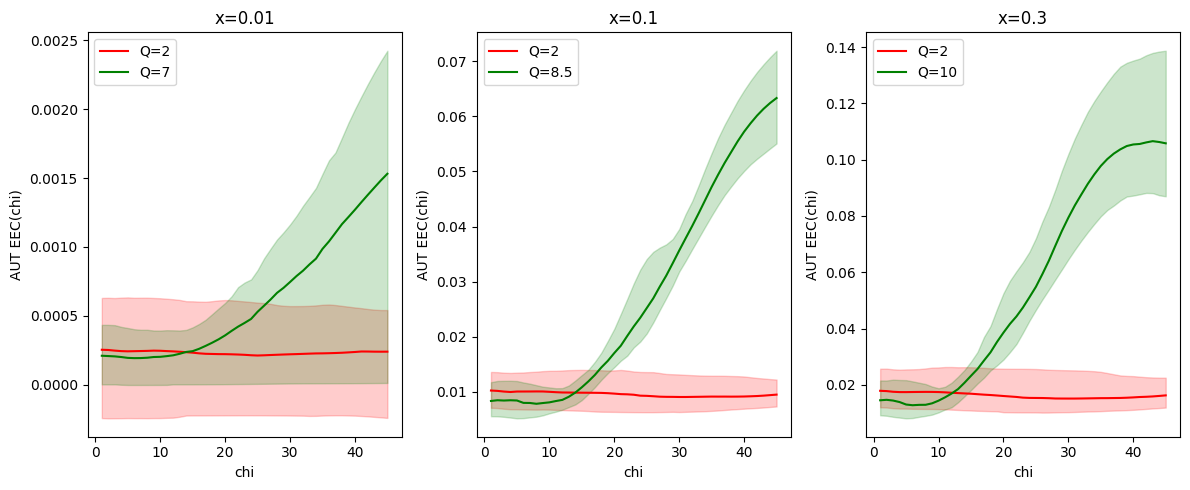

In [11]:
plot_sidis_aut_scan_results(
    scan_results=sidis_scan_results,
    x_q_map=x_q_map,
    title_note=scan_coeffs_path.name,
)


ee EEC AUT Parameter Scan

Test & Warm Up ee AUT

In [12]:
chibar_deg = 30.0
chi_deg = 10.0
chibar = np.deg2rad(chibar_deg)
chi = np.deg2rad(chi_deg)

set_diff_coeffs(0.1, 0.1)

value = Main.EE_EEC_AUT(
    chi=chi,
    chibar=chibar,
    Q=2.0,
    mu=1.0,
    rep=0,
)

warmup_values, warmup_time = Main.EE_EEC_AUT_pmap(
    chi_array=[chi, chi],
    chibar_array=[chibar, chibar],
    Q_array=[2.0, 2.0],
    mu_array=[1.0, 1.0],
    rep=[0, 0],
)

display(value)
display((len(warmup_values), warmup_time))


0.0018870465925354563

(2, 0.167671368)

In [13]:
def _prepare_ee_kinematics(chibar_deg_list, Q_list, chi_deg_array=None):
    if chi_deg_array is None:
        chi_deg_array = np.linspace(1, 30, 30)

    kinematics = {}
    for chibar_deg in chibar_deg_list:
        chibar = np.deg2rad(chibar_deg)
        zbar = (1 - np.cos(chibar)) / 2

        for Q in Q_list:
            chi_deg_valid = []
            chi_valid = []
            for chi_deg in chi_deg_array:
                chi = np.deg2rad(chi_deg)
                z = (1 - np.cos(chi)) / 2
                if np.sqrt(z) * Q > 7 or np.sqrt(zbar) * Q > 7:
                    continue
                chi_deg_valid.append(float(chi_deg))
                chi_valid.append(float(chi))

            if not chi_valid:
                raise ValueError(f"No valid chi points survived for chibar={chibar_deg:g}, Q={Q:g}")

            chi_array = np.asarray(chi_valid, dtype=float)
            kinematics[(float(chibar_deg), float(Q))] = {
                "chibar_deg": float(chibar_deg),
                "Q": float(Q),
                "chibar": float(chibar),
                "chi_deg": np.asarray(chi_deg_valid, dtype=float),
                "chi_array": chi_array,
                "chibar_array": np.full(chi_array.size, float(chibar), dtype=float),
                "Q_array": np.full(chi_array.size, float(Q), dtype=float),
                "mu_array": np.full(chi_array.size, float(c * Q), dtype=float),
            }
    return kinematics


def _run_ee_central_curve(kin):
    values, _ = Main.EE_EEC_AUT_pmap(
        chi_array=kin["chi_array"],
        chibar_array=kin["chibar_array"],
        Q_array=kin["Q_array"],
        mu_array=kin["mu_array"],
        rep=np.zeros(kin["chi_array"].size, dtype=int),
    )
    return np.asarray(values, dtype=float)


def _run_ee_replica_curves(kin, replica_ids):
    n_reps = len(replica_ids)
    n_chi = kin["chi_array"].size
    if n_reps == 0:
        return np.empty((0, n_chi), dtype=float)

    values, _ = Main.EE_EEC_AUT_pmap(
        chi_array=np.tile(kin["chi_array"], n_reps),
        chibar_array=np.tile(kin["chibar_array"], n_reps),
        Q_array=np.tile(kin["Q_array"], n_reps),
        mu_array=np.tile(kin["mu_array"], n_reps),
        rep=np.repeat(replica_ids, n_chi),
    )
    return np.asarray(values, dtype=float).reshape(n_reps, n_chi)


def generate_ee_aut_scan_results(*, chibar_deg_list, Q_list, coeffs_path, replica_ids=None, fit_order="LO", chi_deg_array=None, save_plot_data=True):
    if fit_order != "LO":
        raise ValueError("Only LO is currently supported")

    coeff_grid = _read_scan_coeffs(coeffs_path)
    replica_ids = _normalize_replica_ids(replica_ids)
    scan_label = Path(coeffs_path).stem
    kinematics = _prepare_ee_kinematics(chibar_deg_list, Q_list, chi_deg_array)

    scan_results = {
        "process": "EE_AUT",
        "fit_order": fit_order,
        "scan_label": scan_label,
        "coeffs_path": str(Path(coeffs_path).resolve()),
        "coeff_grid": coeff_grid,
        "replica_ids": replica_ids,
        "chibar_deg_list": [float(value) for value in chibar_deg_list],
        "Q_list": [float(value) for value in Q_list],
        "by_kinematics": {},
    }

    n_coeffs = len(coeff_grid)
    n_reps = len(replica_ids)
    for key, kin in kinematics.items():
        n_chi = kin["chi_array"].size
        scan_results["by_kinematics"][key] = {
            **kin,
            "central_curves": np.empty((n_coeffs, n_chi), dtype=float),
            "replica_curves": np.empty((n_coeffs, n_reps, n_chi), dtype=float),
        }

    total_jobs = n_coeffs * len(kinematics)
    jobs_done = 0
    t0_all = time.perf_counter()

    for icoeff, (a, b) in enumerate(coeff_grid):
        set_diff_coeffs(a, b)
        for (chibar_deg, Q), entry in scan_results["by_kinematics"].items():
            entry["central_curves"][icoeff] = _run_ee_central_curve(entry)
            entry["replica_curves"][icoeff] = _run_ee_replica_curves(entry, replica_ids)
            jobs_done += 1
            _print_progress(jobs_done, total_jobs, t0_all, f"ee a={a:.4f}, b={b:.4f}, chibar={chibar_deg:g}, Q={Q:g}")

    for entry in scan_results["by_kinematics"].values():
        members = entry["replica_curves"].reshape(-1, entry["replica_curves"].shape[-1])
        _apply_percentile_summary(entry, members, entry["central_curves"], "AUT")

    if save_plot_data:
        _save_scan_plot_data(
            scan_results,
            filename="ee_aut.pkl",
            value_prefix="AUT",
            root_keys=["chibar_deg_list", "Q_list"],
            entry_keys=["chibar_deg", "Q", "chibar", "chi_deg", "chi_array", "mu_array"],
        )

    total_elapsed = time.perf_counter() - t0_all
    clear_output(wait=True)
    print(
        f"done | ee scan={scan_label} | "
        f"parameter points={len(coeff_grid)} | replicas={len(replica_ids)} | "
        f"total elapsed: {_format_seconds(total_elapsed)}"
    )

    return scan_results


def plot_ee_aut_scan_results(*, scan_results, chibar_deg_list, Q_list):
    print(f"Results for {scan_results['fit_order']}")
    print(
        f"scan={scan_results['scan_label']} | "
        f"parameter points={len(scan_results['coeff_grid'])} | "
        f"replicas={len(scan_results['replica_ids'])} | central 68%"
    )

    nrows, ncols = 1, len(chibar_deg_list)
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * len(chibar_deg_list), 5))
    axes = np.atleast_1d(axes)
    color_arr = ['r', 'g', 'b', 'y', 'orange', 'cyan']

    for ifig, chibar_deg in enumerate(chibar_deg_list):
        ax1 = axes[ifig]
        for icol, Q in enumerate(Q_list):
            entry = scan_results["by_kinematics"][(float(chibar_deg), float(Q))]
            chi_deg = np.asarray(entry["chi_deg"], dtype=float)
            aut_median = np.asarray(entry["AUT_median"], dtype=float)
            aut_lower_68 = np.asarray(entry["AUT_lower_68"], dtype=float)
            aut_upper_68 = np.asarray(entry["AUT_upper_68"], dtype=float)
            color = color_arr[icol % len(color_arr)]

            ax1.plot(chi_deg, aut_median, color=color, label=f'Q={Q:g}')
            ax1.fill_between(chi_deg, aut_lower_68, aut_upper_68, color=color, alpha=0.2)

        ax1.set_xlabel('chi')
        ax1.set_ylabel('AUT EEC(chi)')
        ax1.set_title(f'chibar={chibar_deg:g}')
        ax1.legend()

    plt.tight_layout()
    plt.show()


In [14]:
chibar_deg_list = [1, 15, 30]
Q_list = [3.65, 10.58]

ee_scan_results = generate_ee_aut_scan_results(
    chibar_deg_list=chibar_deg_list,
    Q_list=Q_list,
    coeffs_path=scan_coeffs_path,
    fit_order="LO",
    chi_deg_array=np.linspace(1, 45, ee_aut_plot_n_points),
)


done | ee scan=a_b_uniform_area_100 | parameter points=100 | replicas=100 | total elapsed: 28m 06s


Results for LO
scan=a_b_uniform_area_100 | parameter points=100 | replicas=100 | central 68%


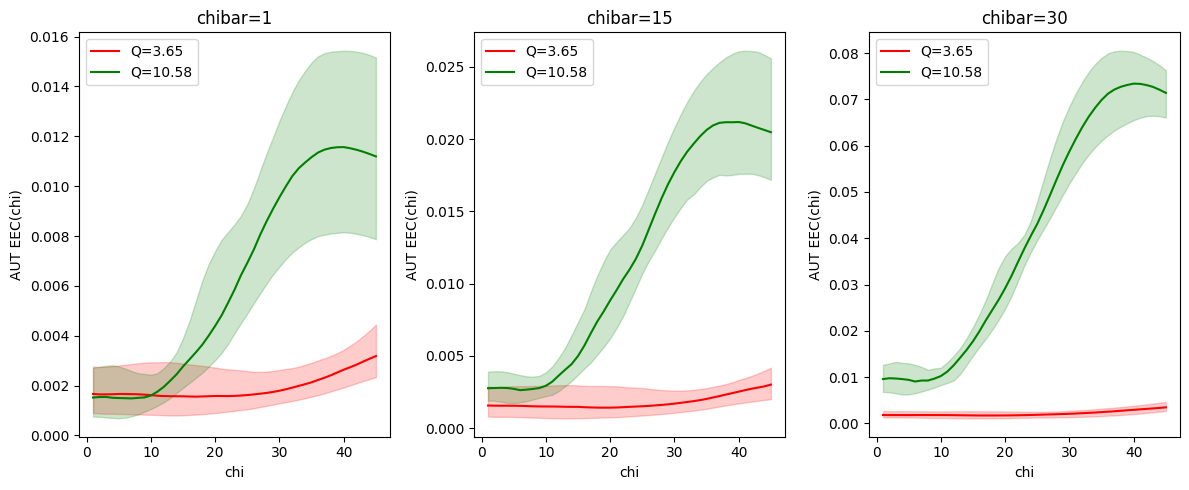

In [15]:
plot_ee_aut_scan_results(
    scan_results=ee_scan_results,
    chibar_deg_list=chibar_deg_list,
    Q_list=Q_list,
)


ee EEC Parameter Scan


In [9]:
print(f"Using ee EEC scan grid from {scan_coeffs_path}")

Using ee EEC scan grid from a_b_uniform_area_100.xlsx


In [10]:
def _prepare_ee_eec_kinematics(Q_list, chi_deg_array=None):
    if chi_deg_array is None:
        chi_deg_array = np.linspace(1, 30, 60)

    chi_deg_array = np.asarray(chi_deg_array, dtype=float)
    chi_array = np.deg2rad(chi_deg_array)

    kinematics = {}
    for Q in Q_list:
        Q = float(Q)
        npts = len(chi_array)
        kinematics[Q] = {
            "Q": Q,
            "chi_deg": chi_deg_array.copy(),
            "chi_array": chi_array.copy(),
            "Q_array": np.full(npts, Q, dtype=float),
            "mu_array": np.full(npts, c * Q, dtype=float),
        }

    return kinematics


def _run_ee_eec_central_curve(kin):
    values, _ = Main.EE_EEC_pmap(
        chi_array=kin["chi_array"],
        Q_array=kin["Q_array"],
        mu_array=kin["mu_array"],
        rep=np.zeros(kin["chi_array"].size, dtype=int),
    )
    return np.asarray(values, dtype=float)


def _run_ee_eec_replica_curves(kin, replica_ids):
    n_reps = len(replica_ids)
    n_chi = kin["chi_array"].size
    if n_reps == 0:
        return np.empty((0, n_chi), dtype=float)

    values, _ = Main.EE_EEC_pmap(
        chi_array=np.tile(kin["chi_array"], n_reps),
        Q_array=np.tile(kin["Q_array"], n_reps),
        mu_array=np.tile(kin["mu_array"], n_reps),
        rep=np.repeat(replica_ids, n_chi),
    )
    return np.asarray(values, dtype=float).reshape(n_reps, n_chi)


def generate_ee_eec_scan_results(*, Q_list, coeffs_path, replica_ids=None, fit_order="LO", chi_deg_array=None, save_plot_data=True):
    if fit_order != "LO":
        raise ValueError("Only LO is currently supported")

    coeff_grid = _read_scan_coeffs(coeffs_path)
    replica_ids = _normalize_replica_ids(replica_ids)
    scan_label = Path(coeffs_path).stem
    kinematics = _prepare_ee_eec_kinematics(Q_list, chi_deg_array=chi_deg_array)

    scan_results = {
        "process": "EE_EEC",
        "fit_order": fit_order,
        "scan_label": scan_label,
        "coeffs_path": str(Path(coeffs_path).resolve()),
        "coeff_grid": coeff_grid,
        "replica_ids": replica_ids,
        "Q_list": [float(Q) for Q in Q_list],
        "by_kinematics": {},
    }

    n_coeffs = len(coeff_grid)
    n_reps = len(replica_ids)
    for key, kin in kinematics.items():
        n_chi = kin["chi_array"].size
        scan_results["by_kinematics"][key] = {
            **kin,
            "central_curves": np.empty((n_coeffs, n_chi), dtype=float),
            "replica_curves": np.empty((n_coeffs, n_reps, n_chi), dtype=float),
        }

    total_jobs = n_coeffs * len(kinematics)
    jobs_done = 0
    t0_all = time.perf_counter()

    for icoeff, (a, b) in enumerate(coeff_grid):
        set_diff_coeffs(a, b)
        for (Q, entry) in scan_results["by_kinematics"].items():
            entry["central_curves"][icoeff] = _run_ee_eec_central_curve(entry)
            entry["replica_curves"][icoeff] = _run_ee_eec_replica_curves(entry, replica_ids)
            jobs_done += 1
            _print_progress(jobs_done, total_jobs, t0_all, f"ee EEC a={a:.4f}, b={b:.4f}, Q={Q:g}")

    for entry in scan_results["by_kinematics"].values():
        members = entry["replica_curves"].reshape(-1, entry["replica_curves"].shape[-1])
        _apply_percentile_summary(entry, members, entry["central_curves"], "EEC")

    if save_plot_data:
        _save_scan_plot_data(
            scan_results,
            filename="ee_eec.pkl",
            value_prefix="EEC",
            root_keys=["Q_list"],
            entry_keys=["Q", "chi_deg", "chi_array", "mu_array"],
        )

    total_elapsed = time.perf_counter() - t0_all
    clear_output(wait=True)
    print(
        f"done | ee EEC scan={scan_label} | "
        f"parameter points={len(coeff_grid)} | replicas={len(replica_ids)} | "
        f"total elapsed: {_format_seconds(total_elapsed)}"
    )

    return scan_results


def plot_ee_eec_scan_results(*, scan_results, Q_list):
    q_values = [float(Q) for Q in Q_list]
    fig, axes = plt.subplots(1, len(q_values), figsize=(5 * len(q_values), 4.5), sharey=False)
    axes = np.atleast_1d(axes)

    experiment_labels = {
        3.65: "BESIII",
        10.58: "BELLE",
    }

    for ax, Q in zip(axes, q_values):
        entry = scan_results["by_kinematics"][Q]
        chi_deg = np.asarray(entry["chi_deg"], dtype=float)
        median = np.asarray(entry["EEC_median"], dtype=float)
        lower_68 = np.asarray(entry["EEC_lower_68"], dtype=float)
        upper_68 = np.asarray(entry["EEC_upper_68"], dtype=float)

        ax.plot(chi_deg, median, color="#c43c39", lw=2.0)
        ax.fill_between(chi_deg, lower_68, upper_68, color="#c43c39", alpha=0.20)

        experiment = experiment_labels.get(Q, "ee")
        ax.set_title(f"{experiment}, Q={Q:g} GeV")
        ax.set_xlabel("chi [deg]")
        ax.set_ylabel("EEC(chi)")
        ax.grid(alpha=0.25)

    fig.suptitle(
        f"Unpolarized ee EEC scan: scan={scan_results['scan_label']}, replicas={len(scan_results['replica_ids'])}, central 68%",
        y=1.02,
    )
    plt.tight_layout()
    plt.show()


done | ee EEC scan=a_b_uniform_area_100 | parameter points=100 | replicas=100 | total elapsed: 3m 30s


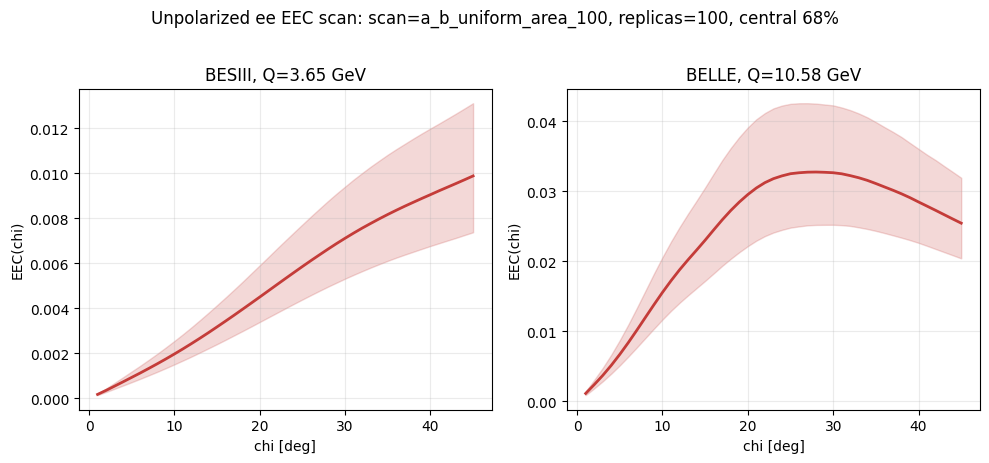

In [11]:
ee_eec_Q_list = [3.65, 10.58]

ee_eec_scan_results = generate_ee_eec_scan_results(
    Q_list=ee_eec_Q_list,
    coeffs_path=scan_coeffs_path,
    replica_ids="loaded",
    chi_deg_array=np.linspace(1, 45, ee_eec_plot_n_points),
)

plot_ee_eec_scan_results(
    scan_results=ee_eec_scan_results,
    Q_list=ee_eec_Q_list,
)


SIDIS EEC Replica Prediction


In [ ]:
include("Splitting/moments.jl")
include("DiFF_EEC/DiFF_EEC_own.jl")
include("Processes/SIDIS/SIDIS_EEC.jl")

sidis_eec_params_path = Path("../../DiFF/EECs_AUT_code/JAMDiFF_library/EEC_DiFF_replicas/params_LO_Q.xlsx")
sidis_eec_central_params = np.asarray([0.035, 150.0, 10.1], dtype=float)
sidis_eec_pdfset_name = str(Main.eval('pdf_dict_array[1]["pdfset_name"]'))

try:
    import lhapdf
except ImportError:
    lhapdf = None

def _default_sidis_eec_pdf_member_ids():
    if lhapdf is not None:
        try:
            return np.arange(1, len(lhapdf.mkPDFs(sidis_eec_pdfset_name)), dtype=int)
        except Exception:
            pass
    if sidis_eec_pdfset_name == "CT18NLO":
        return np.arange(1, 59, dtype=int)
    raise RuntimeError(
        f"Could not determine positive PDF members for {sidis_eec_pdfset_name}; pass pdf_member_ids explicitly."
    )

sidis_eec_pdf_member_ids = _default_sidis_eec_pdf_member_ids()

Main.eval("""
function SIDIS_EEC_pmap_ascii(; chi_array, x_array, Q_array, mu_array)
    return SIDIS_EEC_pmap(chi_array=chi_array, x_array=x_array, Q_array=Q_array, μ_array=mu_array)
end
""")

print(f"Using SIDIS EEC parameter replicas from {sidis_eec_params_path}")
print(f"Using unpolarized PDF set {sidis_eec_pdfset_name} with {len(sidis_eec_pdf_member_ids)} error members")


In [ ]:
def _read_sidis_eec_parameter_members(path):
    path = Path(path)
    df = pd.read_excel(path)
    if df.shape[0] < 3:
        raise ValueError(f"Expected three parameter rows in {path}")

    param_columns = [col for col in df.columns if str(col).startswith("params")]
    if not param_columns:
        raise ValueError(f"No parameter replica columns found in {path}")

    values = df.loc[:2, param_columns].apply(pd.to_numeric, errors="coerce").to_numpy(dtype=float).T
    if np.isnan(values).any():
        raise ValueError(f"Found non-numeric parameter replica values in {path}")

    member_ids = np.asarray([int(str(col).removeprefix("params")) for col in param_columns], dtype=int)
    return values, member_ids


def _normalize_sidis_eec_pdf_member_ids(pdf_member_ids=None):
    if pdf_member_ids is None:
        return sidis_eec_pdf_member_ids.copy()

    pdf_member_ids = np.asarray(pdf_member_ids, dtype=int)
    if pdf_member_ids.ndim != 1:
        raise ValueError("pdf_member_ids must be one-dimensional")
    if pdf_member_ids.size == 0:
        return pdf_member_ids

    unknown = np.setdiff1d(pdf_member_ids, sidis_eec_pdf_member_ids)
    if unknown.size:
        raise ValueError(f"Requested PDF members were not loaded by default: {unknown.tolist()}")
    return np.unique(pdf_member_ids)


def _set_sidis_eec_params(params):
    p0_val, p1_val, p2_val = np.asarray(params, dtype=float)
    Main.p0 = float(p0_val)
    Main.p1 = float(p1_val)
    Main.p2 = float(p2_val)


def _set_sidis_eec_pdf_member(member):
    Main.set_lhapdf(0, sidis_eec_pdfset_name, int(member))


def _run_sidis_eec_curve(kin):
    values, _ = Main.SIDIS_EEC_pmap_ascii(
        chi_array=kin["chi_array"],
        x_array=kin["x_array"],
        Q_array=kin["Q_array"],
        mu_array=kin["mu_array"],
    )
    return np.asarray(values, dtype=float)


def _save_sidis_eec_plot_data(scan_results):
    payload = {
        "card_name": card_name,
        "process": scan_results["process"],
        "fit_order": scan_results["fit_order"],
        "params_path": scan_results["params_path"],
        "pdfset_name": scan_results["pdfset_name"],
        "pdf_member_ids": np.asarray(scan_results["pdf_member_ids"], dtype=int),
        "parameter_member_ids": np.asarray(scan_results["parameter_member_ids"], dtype=int),
        "central_params": np.asarray(scan_results["central_params"], dtype=float),
        "percentiles": PERCENTILE_LEVELS.copy(),
        "x_values": list(scan_results["x_values"]),
        "x_to_q": {float(x): [float(Q) for Q in q_values] for x, q_values in scan_results["x_to_q"].items()},
        "by_kinematics": {},
    }

    for key, entry in scan_results["by_kinematics"].items():
        payload["by_kinematics"][key] = {
            "x": float(entry["x"]),
            "Q": float(entry["Q"]),
            "chi_deg": np.asarray(entry["chi_deg"], dtype=float),
            "chi_array": np.asarray(entry["chi_array"], dtype=float),
            "mu_array": np.asarray(entry["mu_array"], dtype=float),
            "central_curve": np.asarray(entry["central_curve"], dtype=float),
            "percentile_16": np.asarray(entry["EEC_percentile_16"], dtype=float),
            "percentile_50": np.asarray(entry["EEC_percentile_50"], dtype=float),
            "percentile_84": np.asarray(entry["EEC_percentile_84"], dtype=float),
            "median": np.asarray(entry["EEC_median"], dtype=float),
            "lower_68": np.asarray(entry["EEC_lower_68"], dtype=float),
            "upper_68": np.asarray(entry["EEC_upper_68"], dtype=float),
            "n_members": int(entry["n_members"]),
        }

    path = _save_plot_data("sidis_eec.pkl", payload)
    scan_results["plot_data_path"] = str(path)
    return path


def generate_sidis_eec_results(*, x_list=None, Q_list=None, x_q_map=None, params_path=sidis_eec_params_path, pdf_member_ids=None, fit_order="LO", chi_deg_array=None, save_plot_data=True):
    if fit_order != "LO":
        raise ValueError("Only LO is currently supported")

    parameter_members, parameter_member_ids = _read_sidis_eec_parameter_members(params_path)
    pdf_member_ids = _normalize_sidis_eec_pdf_member_ids(pdf_member_ids)
    x_values, x_to_q, kinematics = _prepare_sidis_kinematics(
        x_list=x_list,
        Q_list=Q_list,
        x_q_map=x_q_map,
        chi_deg_array=chi_deg_array,
    )

    scan_results = {
        "process": "SIDIS_EEC",
        "fit_order": fit_order,
        "params_path": str(Path(params_path).resolve()),
        "pdfset_name": sidis_eec_pdfset_name,
        "pdf_member_ids": pdf_member_ids,
        "parameter_member_ids": parameter_member_ids,
        "central_params": sidis_eec_central_params.copy(),
        "x_values": x_values,
        "x_to_q": x_to_q,
        "by_kinematics": {},
    }

    n_params = len(parameter_member_ids)
    n_pdf = len(pdf_member_ids)
    for key, kin in kinematics.items():
        n_chi = kin["chi_array"].size
        scan_results["by_kinematics"][key] = {
            **kin,
            "central_curve": np.empty(n_chi, dtype=float),
            "replica_curves": np.empty((n_params, n_pdf, n_chi), dtype=float),
        }

    _set_sidis_eec_pdf_member(0)
    _set_sidis_eec_params(sidis_eec_central_params)
    for entry in scan_results["by_kinematics"].values():
        entry["central_curve"] = _run_sidis_eec_curve(entry)

    total_jobs = max(len(kinematics) * max(n_params, 1) * max(n_pdf, 1), 1)
    jobs_done = 0
    t0_all = time.perf_counter()

    for ipdf, pdf_member in enumerate(pdf_member_ids):
        _set_sidis_eec_pdf_member(pdf_member)
        for iparam, params in enumerate(parameter_members):
            _set_sidis_eec_params(params)
            for (x, Q), entry in scan_results["by_kinematics"].items():
                entry["replica_curves"][iparam, ipdf] = _run_sidis_eec_curve(entry)
                jobs_done += 1
                _print_progress(
                    jobs_done,
                    total_jobs,
                    t0_all,
                    f"SIDIS EEC pdf={pdf_member}, param={parameter_member_ids[iparam]}, x={x:.2f}, Q={Q:g}",
                )

    _set_sidis_eec_pdf_member(0)
    _set_sidis_eec_params(sidis_eec_central_params)

    for entry in scan_results["by_kinematics"].values():
        members = entry["replica_curves"].reshape(-1, entry["replica_curves"].shape[-1])
        _apply_percentile_summary(entry, members, entry["central_curve"][None, :], "EEC")

    if save_plot_data:
        _save_sidis_eec_plot_data(scan_results)

    total_elapsed = time.perf_counter() - t0_all
    clear_output(wait=True)
    print(
        f"done | SIDIS EEC pdf members={len(pdf_member_ids)} | parameter members={len(parameter_member_ids)} | "
        f"total elapsed: {_format_seconds(total_elapsed)}"
    )

    return scan_results


def plot_sidis_eec_results(*, scan_results, x_list=None, Q_list=None, x_q_map=None, title_note=None):
    print(
        f"SIDIS EEC | pdf members={len(scan_results['pdf_member_ids'])} | "
        f"parameter members={len(scan_results['parameter_member_ids'])} | central 68%"
    )
    if title_note is not None:
        print(title_note)

    x_values, x_to_q, _ = _resolve_x_q_inputs(x_list=x_list, Q_list=Q_list, x_q_map=x_q_map)
    fig, axes = plt.subplots(1, len(x_values), figsize=(4 * len(x_values), 5))
    axes = np.atleast_1d(axes)
    color_arr = ['r', 'g', 'b', 'y', 'orange', 'cyan']

    for ifig, x in enumerate(x_values):
        ax1 = axes[ifig]
        for icol, Q in enumerate(x_to_q[x]):
            entry = scan_results["by_kinematics"][(float(x), float(Q))]
            chi_deg = np.asarray(entry["chi_deg"], dtype=float)
            median = np.asarray(entry["EEC_median"], dtype=float)
            lower_68 = np.asarray(entry["EEC_lower_68"], dtype=float)
            upper_68 = np.asarray(entry["EEC_upper_68"], dtype=float)
            color = color_arr[icol % len(color_arr)]

            ax1.plot(chi_deg, median, color=color, label=f'Q={Q:g}')
            ax1.fill_between(chi_deg, lower_68, upper_68, color=color, alpha=0.2)

        ax1.set_xlabel('chi')
        ax1.set_ylabel('EEC(chi)')
        ax1.set_title(f'x={x}')
        ax1.legend()

    plt.tight_layout()
    plt.show()


In [ ]:
sidis_eec_results = generate_sidis_eec_results(
    x_q_map=x_q_map,
    params_path=sidis_eec_params_path,
    chi_deg_array=np.linspace(1, 45, sidis_plot_n_points),
)

plot_sidis_eec_results(
    scan_results=sidis_eec_results,
    x_q_map=x_q_map,
    title_note=sidis_eec_params_path.name,
)
